# NutriTrack - Phase 1: Real-Data Cleaning, EDA & Diabetes Insights
**Author:** Abhijith Nallana

## Project introduction
NutriTrack combines real **USDA Foundation Foods** nutrition measurements with the real
**NHANES 2017–2018** health survey. Phase 1 covers the full data pipeline: loading the
official source files, cleaning them, a complete exploratory data analysis (EDA), and
descriptive diabetes-risk insights. The cleaned tables are written to a SQLite database
that the Streamlit app reads.

**Scope.** Phase 1 is descriptive only. It does **not** diagnose diabetes and contains
**no machine-learning model** - prediction is Phase 2. Missing values are either kept or
handled explicitly; no synthetic nutrition or health values are invented.

**How to read this notebook.** Each code cell is followed by an *Interpretation* that
explains the concept and what the output means. Every section ends with a takeaway, so the
notebook reads as an analytical narrative rather than a sequence of plots.

**Pipeline:** `raw CSV/XPT files → load → clean → EDA → diabetes insights → SQLite`.

## Setup and official source files
USDA: download the latest **Foundation Foods CSV** ZIP from https://fdc.nal.usda.gov/download-datasets, extract it under `data/raw/usda/`, and retain `food.csv`, `food_nutrient.csv`, and `nutrient.csv`.

NHANES 2017-2018 files are downloaded below from CDC: `DEMO_J`, `BMX_J`, `GLU_J`, `DIQ_J`, `PAQ_J`, and `DR1TOT_J`. `PAQ` is required for physical activity; `DR1TOT` is required to analyze participant nutrition patterns by diabetes status.

In [1]:
from pathlib import Path
import sqlite3
import urllib.request
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
USDA_DIR = PROJECT_ROOT / 'data' / 'raw' / 'usda'
NHANES_DIR = PROJECT_ROOT / 'data' / 'raw' / 'nhanes'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
DB_PATH = PROJECT_ROOT / 'database' / 'nutritrack.db'
for folder in [USDA_DIR, NHANES_DIR, PROCESSED_DIR, DB_PATH.parent]: folder.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 100)
PROJECT_ROOT

WindowsPath('C:/Users/Abhijith Nallana/Desktop/data-science-roadmap/Project')

**Interpretation.** The project paths resolve relative to the notebook's location, so the
code runs unchanged on any machine, and the data/processed/database folders are created if
absent. With the environment ready, we load the official source files.

## Section 2 - Load USDA Foundation Foods
USDA nutrient values are standardized to amounts **per 100 g**. The official nutrient IDs mapped here are Energy (1008), Protein (1003), Carbohydrate (1005), Total fat (1004), Fiber (1079), Total sugars (2000), and Sodium (1093).

In [2]:
def find_usda_file(filename):
    matches = list(USDA_DIR.rglob(filename))
    if not matches:
        raise FileNotFoundError(f'{filename} not found under {USDA_DIR}. Download and extract the official USDA Foundation Foods CSV ZIP first.')
    return matches[0]

food_raw = pd.read_csv(find_usda_file('food.csv'), low_memory=False)
food_nutrient_raw = pd.read_csv(find_usda_file('food_nutrient.csv'), low_memory=False)
nutrient_raw = pd.read_csv(find_usda_file('nutrient.csv'), low_memory=False)
print('food.csv shape:', food_raw.shape)
display(food_raw.head(20))
print('food_nutrient.csv shape:', food_nutrient_raw.shape)
display(food_nutrient_raw.head())
print('nutrient.csv shape:', nutrient_raw.shape)
display(nutrient_raw.head())
display(food_raw.dtypes.to_frame('dtype'))

food.csv shape: (87990, 5)


,fdc_id,data_type,description,food_category_id,publication_date
0,319874,sample_food,"HUMMUS, SABRA CLASSIC",16.0,2019-04-01
1,319875,market_acquisition,"HUMMUS, SABRA CLASSIC",16.0,2019-04-01
2,319876,market_acquisition,"HUMMUS, SABRA CLASSIC",16.0,2019-04-01
3,319877,sub_sample_food,Hummus,16.0,2019-04-01
4,319878,sub_sample_food,Hummus,16.0,2019-04-01
5,319879,sample_food,"HUMMUS, SABRA CLASSIC",16.0,2019-04-01
6,319880,market_acquisition,"HUMMUS, SABRA CLASSIC",16.0,2019-04-01
7,319881,market_acquisition,"HUMMUS, SABRA CLASSIC",16.0,2019-04-01
8,319882,sub_sample_food,Hummus,16.0,2019-04-01
9,319883,sub_sample_food,Hummus,16.0,2019-04-01


food_nutrient.csv shape: (170469, 11)


,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
0,2201847,319877,1051,56.30,1.0,1.0,NaN,NaN,NaN,NaN,NaN
1,2201845,319877,1002,1.28,1.0,1.0,NaN,NaN,NaN,NaN,NaN
2,2201846,319877,1004,19.00,1.0,1.0,NaN,NaN,NaN,NaN,NaN
3,2201844,319877,1007,1.98,1.0,1.0,NaN,NaN,NaN,NaN,NaN
4,2201852,319878,1091,188.00,1.0,1.0,NaN,NaN,NaN,NaN,NaN


nutrient.csv shape: (477, 5)


,id,name,unit_name,nutrient_nbr,rank
0,2047,Energy (Atwater General Factors),KCAL,957.0,280.0
1,2048,Energy (Atwater Specific Factors),KCAL,958.0,290.0
2,1001,Solids,G,201.0,200.0
3,1002,Nitrogen,G,202.0,500.0
4,1003,Protein,G,203.0,600.0


,dtype
fdc_id,int64
data_type,object
description,object
food_category_id,float64
publication_date,object


**Interpretation.** The raw USDA `food.csv` holds **87,990** records spanning every USDA
data type. That is the full catalog; next we narrow to the *Foundation Foods* subset, which
carries the highest-quality, laboratory-measured nutrient values.

In [3]:
# USDA stores energy under up to three nutrient IDs. Foundation Foods often omit
# 1008 (Energy kcal) but include 2047 (Atwater General) or 2048 (Atwater Specific).
# We coalesce them in preference order (specific > general > generic) so we keep
# far more foods instead of dropping every food that lacks ID 1008.
NUTRIENT_MAP = {1003:'protein', 1005:'carbs', 1004:'fat', 1079:'fiber', 2000:'sugar', 1093:'sodium'}
ENERGY_RANK = {2048:0, 2047:1, 1008:2}  # lower rank = preferred

foundation = food_raw.loc[food_raw['data_type'].eq('foundation_food'), ['fdc_id','description']].copy()
fn = food_nutrient_raw[['fdc_id','nutrient_id','amount']]

# Non-energy nutrients pivoted into columns.
values = fn[fn['nutrient_id'].isin(NUTRIENT_MAP)].copy()
# Adding extra column "field" and keeping the mapped values
values['field'] = values['nutrient_id'].map(NUTRIENT_MAP)
wide = values.pivot_table(index='fdc_id', columns='field', values='amount', aggfunc='mean').reset_index()

# Energy: keep the single most-preferred value available per food.
energy = fn[fn['nutrient_id'].isin(ENERGY_RANK)].copy()
energy['rank'] = energy['nutrient_id'].map(ENERGY_RANK)
energy = (energy.sort_values('rank').drop_duplicates('fdc_id', keep='first')
                [['fdc_id','amount']].rename(columns={'amount':'calories'}))

foods = (foundation.merge(energy, on='fdc_id', how='left')
                   .merge(wide, on='fdc_id', how='left')
                   .rename(columns={'description':'food_name'}))
print(foods)
foods = foods[['fdc_id','food_name','calories','protein','carbs','fat','fiber','sugar','sodium']]
print('USDA Foundation Foods extracted:', foods.shape)
display(foods.head())

      fdc_id                                          food_name  calories  \
0     321358                                 Hummus, commercial  229.0000   
1     321359  Milk, reduced fat, fluid, 2% milkfat, with add...   50.0000   
2     321360                               Tomatoes, grape, raw   27.0000   
3     321505                               Salt, table, iodized       NaN   
4     321611  Beans, snap, green, canned, regular pack, drai...   20.0000   
..       ...                                                ...       ...   
464  2759003         Lunchmeat, roast beef, sliced, prepackaged       NaN   
465  2759004                  Lunchmeat, chicken breast, sliced       NaN   
466  2759005                               Salami, hard, sliced       NaN   
467  2759006                   Pepperoni, beef and pork, sliced       NaN   
468  2768188                                Alaska Pollock, raw   78.4785   

       carbs      fat  fiber  protein   sodium  sugar  
0    14.9000  17.10

,fdc_id,food_name,calories,protein,carbs,fat,fiber,sugar,sodium
0,321358,"Hummus, commercial",229.0,7.35,14.90,17.10,5.4,NaN,438.0
1,321359,"Milk, reduced fat, fluid, 2% milkfat, with add...",50.0,3.35,4.91,1.90,NaN,NaN,39.0
2,321360,"Tomatoes, grape, raw",27.0,0.83,5.51,0.63,2.1,NaN,6.0
3,321505,"Salt, table, iodized",NaN,NaN,NaN,NaN,NaN,NaN,38700.0
4,321611,"Beans, snap, green, canned, regular pack, drai...",20.0,1.04,4.11,0.39,NaN,NaN,282.0


**Interpretation.** Filtering to Foundation Foods and coalescing the three USDA energy IDs
yields **469** foods with full nutrient columns. Pulling energy from IDs 2047/2048 as well as
1008 is essential - most Foundation Foods omit 1008, so relying on it alone would shrink the
catalog to ~135 foods. This is the most important data decision in the USDA branch.

## Section 3 - Load and merge NHANES
Files are merged by the respondent identifier `SEQN`. The selected variables cover demographics, body measures, fasting glucose, diabetes questionnaire status, physical activity, and day-one dietary totals.

In [4]:
NHANES_FILES = ['DEMO_J','BMX_J','GLU_J','DIQ_J','PAQ_J','DR1TOT_J']
for stem in NHANES_FILES:
    target = NHANES_DIR / f'{stem}.XPT'
    if not target.exists():
        url = f'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/{stem}.xpt'
        print('Downloading', url)
        urllib.request.urlretrieve(url, target)

#.xpt file is SAS file format
frames = {stem: pd.read_sas(NHANES_DIR / f'{stem}.XPT', format='xport') for stem in NHANES_FILES}
for name, frame in frames.items(): print(name, frame.shape)
nhanes_raw = frames['DEMO_J']
for stem in NHANES_FILES[1:]: nhanes_raw = nhanes_raw.merge(frames[stem], on='SEQN', how='left')
print('Merged shape:', nhanes_raw.shape)
display(nhanes_raw.head())
display(nhanes_raw.isna().sum().sort_values(ascending=False).head(20).to_frame('missing'))

DEMO_J (9254, 46)
BMX_J (8704, 21)
GLU_J (3036, 4)
DIQ_J (8897, 54)
PAQ_J (5856, 17)
DR1TOT_J (8704, 168)
Merged shape: (9254, 305)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,DMQMILIZ,DMQADFC,DMDBORN4,DMDCITZN,DMDYRSUS,DMDEDUC3,DMDEDUC2,DMDMARTL,RIDEXPRG,SIALANG,SIAPROXY,SIAINTRP,FIALANG,FIAPROXY,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANGA,DMDHHSIZ,DMDFMSIZ,DMDHHSZA,DMDHHSZB,DMDHHSZE,DMDHRGND,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR,BMDSTATS,BMXWT,BMIWT,BMXRECUM,...,DRD350HQ,DRD350I,DRD350IQ,DRD350J,DRD350JQ,DRD350K,DRD360,DRD370A,DRD370AQ,DRD370B,DRD370BQ,DRD370C,DRD370CQ,DRD370D,DRD370DQ,DRD370E,DRD370EQ,DRD370F,DRD370FQ,DRD370G,DRD370GQ,DRD370H,DRD370HQ,DRD370I,DRD370IQ,DRD370J,DRD370JQ,DRD370K,DRD370KQ,DRD370L,DRD370LQ,DRD370M,DRD370MQ,DRD370N,DRD370NQ,DRD370O,DRD370OQ,DRD370P,DRD370PQ,DRD370Q,DRD370QQ,DRD370R,DRD370RQ,DRD370S,DRD370SQ,DRD370T,DRD370TQ,DRD370U,DRD370UQ,DRD370V
0,93703.0,10.0,2.0,2.0,2.0,NaN,5.0,6.0,2.0,27.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,2.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,5.0,5.0,3.000000e+00,5.397605e-79,5.397605e-79,1.0,2.0,3.0,1.0,3.0,9246.491865,8539.731348,2.0,145.0,15.0,15.0,5.00,1.0,13.7,3.0,89.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,10.0,2.0,1.0,2.0,NaN,3.0,3.0,1.0,33.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,2.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,4.0,4.0,2.000000e+00,5.397605e-79,5.397605e-79,1.0,2.0,3.0,1.0,2.0,37338.768343,42566.614750,1.0,143.0,15.0,15.0,5.00,1.0,13.9,NaN,95.0,...,2.0,2.0,NaN,2.0,NaN,2.0,1.0,1.0,1.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0,1.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0
2,93705.0,10.0,2.0,2.0,66.0,NaN,4.0,4.0,2.0,NaN,2.0,NaN,1.0,1.0,NaN,NaN,2.0,3.0,NaN,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,1.000000e+00,2.0,4.0,1.0,2.0,NaN,8614.571172,8338.419786,2.0,145.0,3.0,3.0,0.82,1.0,79.5,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,93706.0,10.0,2.0,1.0,18.0,NaN,5.0,6.0,2.0,222.0,2.0,NaN,1.0,1.0,NaN,15.0,NaN,NaN,NaN,1.0,2.0,2.0,NaN,NaN,NaN,1.0,2.0,2.0,1.0,5.0,5.0,5.397605e-79,5.397605e-79,1.000000e+00,1.0,4.0,3.0,1.0,2.0,8548.632619,8723.439814,2.0,134.0,NaN,NaN,NaN,1.0,66.3,NaN,NaN,...,NaN,2.0,NaN,2.0,NaN,2.0,1.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0,1.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0,3.0,2.0,NaN,1.0,3.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0
4,93707.0,10.0,2.0,1.0,13.0,NaN,5.0,7.0,2.0,158.0,NaN,NaN,1.0,1.0,NaN,6.0,NaN,NaN,NaN,1.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,7.0,7.0,5.397605e-79,3.000000e+00,5.397605e-79,1.0,3.0,2.0,1.0,3.0,6769.344567,7064.609730,1.0,138.0,10.0,10.0,1.88,1.0,45.4,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing
BMIHEAD,9254
DIQ175X,9252
DRQSDT5,9252
DRQSDT6,9250
DIQ175W,9249
DRD370PQ,9248
DRD370JQ,9247
DRQSDT12,9244
DRD350JQ,9242
DIQ175V,9240


**Interpretation.** Each NHANES file is keyed by `SEQN` but covers a different number of
people: demographics (DEMO_J) has all **9,254** respondents, while fasting glucose (GLU_J)
has only **3,036** because it is a fasting subsample. The left-merge on `SEQN` keeps every
demographic respondent and attaches measurements where they exist - the reason glucose later
shows heavy, *structured* missingness.

## Section 4 - Data Cleaning
USDA: keep real Foundation Foods records, remove duplicate FDC IDs/names, convert nutrient columns to numeric, and drop foods missing calories because they cannot support meal calculations. Missing optional nutrients are retained as missing rather than replaced with invented values.

NHANES: select and rename required variables, convert valid questionnaire codes, calculate physical activity from reported moderate/vigorous weekly minutes, remove duplicate respondents, and retain missing values. Diabetes indicator is based on self-reported doctor diagnosis (`DIQ010`: yes=1, no/borderline=0; refused/don't know=missing).

In [5]:
nutrients = ['calories','protein','carbs','fat','fiber','sugar','sodium']
foods[nutrients] = foods[nutrients].apply(pd.to_numeric, errors='coerce')
foods = foods.drop_duplicates('fdc_id').drop_duplicates('food_name').dropna(subset=['food_name','calories'])
foods = foods[(foods['calories'] >= 0) & (foods['calories'] <= 1000)].reset_index(drop=True)

cols = {'SEQN':'seqn','RIDAGEYR':'age','RIAGENDR':'gender','BMXHT':'height','BMXWT':'weight','BMXBMI':'bmi','LBXGLU':'glucose','DIQ010':'diabetes_code','PAQ650':'vigorous','PAQ655':'vigorous_days','PAD660':'vigorous_minutes','PAQ665':'moderate','PAQ670':'moderate_days','PAD675':'moderate_minutes','DR1TKCAL':'diet_calories','DR1TPROT':'diet_protein','DR1TCARB':'diet_carbs','DR1TTFAT':'diet_fat','DR1TSUGR':'diet_sugar','DR1TFIBE':'diet_fiber'}
nhanes = nhanes_raw[list(cols)].rename(columns=cols).drop_duplicates('seqn').copy()
nhanes['gender'] = nhanes['gender'].map({1:'Male', 2:'Female'})
nhanes['diabetes_indicator'] = nhanes['diabetes_code'].map({1:1, 2:0, 3:0})

# NHANES codes "refused"/"don't know" as 7/9 in the day variables and 7777/9999 in
# the minute variables. Multiplying those directly would inflate activity to absurd
# values (e.g. 9999 minutes). Cap implausible values to NaN BEFORE the calculation,
# then treat any missing component as zero contribution.
for c in ['vigorous_days', 'moderate_days']:
    nhanes[c] = nhanes[c].where(nhanes[c] <= 7)
for c in ['vigorous_minutes', 'moderate_minutes']:
    nhanes[c] = nhanes[c].where(nhanes[c] <= 840)
vigorous = np.where(nhanes['vigorous'].eq(1),
                    nhanes['vigorous_days'].fillna(0) * nhanes['vigorous_minutes'].fillna(0) * 2, 0)
moderate = np.where(nhanes['moderate'].eq(1),
                    nhanes['moderate_days'].fillna(0) * nhanes['moderate_minutes'].fillna(0), 0)
nhanes['physical_activity'] = vigorous + moderate

nhanes = nhanes.drop(columns=['diabetes_code','vigorous','vigorous_days','vigorous_minutes','moderate','moderate_days','moderate_minutes'])
for col in nhanes.columns.difference(['gender']):
    nhanes[col] = pd.to_numeric(nhanes[col], errors='coerce')
print('Clean foods:', foods.shape, 'duplicates:', foods.duplicated().sum())
print('Clean NHANES:', nhanes.shape, 'duplicates:', nhanes.duplicated('seqn').sum())
print('physical_activity -> max:', nhanes['physical_activity'].max(), '| mean:', round(nhanes['physical_activity'].mean(), 1))
display(nhanes.isna().sum().to_frame('missing'))

Clean foods: (328, 9) duplicates: 0
Clean NHANES: (9254, 15) duplicates: 0
physical_activity -> max: 6860.0 | mean: 135.7


,missing
seqn,0
age,0
gender,0
height,1238
weight,674
bmi,1249
glucose,6363
diet_calories,1770
diet_protein,1770
diet_carbs,1770


**Interpretation.** Cleaning leaves **328 foods** (those with a valid calorie value, de-duped)
and all **9,254** NHANES respondents, no duplicates in either. The capped `physical_activity`
now maxes at **6,860** instead of ~140,000 - proof the NHANES `9999` "don't know" codes no
longer leak into the calculation. The data is analysis-ready.

## Exploratory Data Analysis (EDA)

This section applies the formal EDA workflow from class to the cleaned data:
basic structure, descriptive statistics, central tendency and dispersion, the
missing-value problem and imputation (with before/after distributions), skewness,
class balance, and multivariate views (scatter matrix and pair plot). It mirrors
the lecture notes step by step. We work on a copy (`eda`) so the table saved to
SQLite is unchanged.

In [6]:
# A working copy so the EDA / imputation demo does not affect the saved table.
eda = nhanes.copy()
print('Shape:', eda.shape)
eda.info()

Shape: (9254, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9254 entries, 0 to 9253
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   seqn                9254 non-null   float64
 1   age                 9254 non-null   float64
 2   gender              9254 non-null   object 
 3   height              8016 non-null   float64
 4   weight              8580 non-null   float64
 5   bmi                 8005 non-null   float64
 6   glucose             2891 non-null   float64
 7   diet_calories       7484 non-null   float64
 8   diet_protein        7484 non-null   float64
 9   diet_carbs          7484 non-null   float64
 10  diet_fat            7484 non-null   float64
 11  diet_sugar          7484 non-null   float64
 12  diet_fiber          7484 non-null   float64
 13  diabetes_indicator  8893 non-null   float64
 14  physical_activity   9254 non-null   float64
dtypes: float64(14), object(1)
memory usag

**Interpretation.** `.info()` confirms 9,254 rows × 15 columns and exposes the missing-data
pattern: `seqn`/`age` are fully populated, but `glucose` and the `diet_*` fields have far fewer
non-null entries. Every column is numeric except `gender` (the decoded text label). This is the
structural baseline for the EDA.

### Basic info and descriptive statistics

In [7]:
display(eda.head())
eda.describe().T.round(2)

,seqn,age,gender,height,weight,bmi,glucose,diet_calories,diet_protein,diet_carbs,diet_fat,diet_sugar,diet_fiber,diabetes_indicator,physical_activity
0,93703.0,2.0,Female,88.6,13.7,17.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,93704.0,2.0,Male,94.2,13.9,15.7,NaN,1230.0,51.58,160.46,43.24,76.97,5.9,0.0,0.0
2,93705.0,66.0,Female,158.3,79.5,31.7,NaN,1202.0,20.01,157.45,56.98,91.55,8.4,0.0,120.0
3,93706.0,18.0,Male,175.7,66.3,21.5,NaN,1987.0,94.19,89.82,137.39,14.73,7.1,0.0,60.0
4,93707.0,13.0,Male,158.4,45.4,18.1,NaN,1775.0,59.48,188.15,89.18,84.22,10.9,0.0,0.0


,count,mean,std,min,25%,50%,75%,max
seqn,9254.0,98329.50,2671.54,93703.0,96016.25,98329.50,100642.75,102956.00
age,9254.0,34.33,25.50,0.0,11.00,31.00,58.00,80.00
height,8016.0,156.59,22.26,78.3,151.40,161.90,171.20,197.70
weight,8580.0,65.14,32.89,3.2,43.10,67.75,85.60,242.60
bmi,8005.0,26.58,8.26,12.3,20.40,25.80,31.30,86.20
glucose,2891.0,111.80,35.53,47.0,96.00,102.00,113.00,451.00
diet_calories,7484.0,1985.16,988.64,0.0,1307.00,1811.00,2470.00,12501.00
diet_protein,7484.0,72.74,41.55,0.0,44.80,65.14,91.78,545.20
diet_carbs,7484.0,240.03,124.66,0.0,156.68,219.04,299.10,1476.76
diet_fat,7484.0,79.77,47.30,0.0,46.85,70.42,101.50,567.96


**Interpretation.** `.describe()` surfaces three things. (1) `age` starts at **0** - NHANES
surveys all ages, so the sample includes children; a Phase-2 refinement is to restrict to adults.
(2) `glucose`'s mean sits well above its median - the signature of a right-skewed variable with
high outliers. (3) `seqn` is only an identifier, so its statistics are meaningless. Differing
counts re-confirm the missingness from `.info()`.

### Measures of central tendency and dispersion

The lecture covered mean/median/mode (central tendency) and variance, standard
deviation, range, and IQR (dispersion). Here they are for fasting glucose.

In [8]:
feature = 'glucose'
s = eda[feature].dropna()
pd.DataFrame({
    'statistic': ['mean', 'median', 'mode', 'std dev', 'variance', 'range', 'IQR'],
    'value': [s.mean(), s.median(), s.mode().iloc[0], s.std(), s.var(),
              s.max() - s.min(), s.quantile(0.75) - s.quantile(0.25)],
}).round(2)

,statistic,value
0,mean,111.80
1,median,102.00
2,mode,97.00
3,std dev,35.53
4,variance,1262.60
5,range,404.00
6,IQR,17.00


**Interpretation.** Central tendency and dispersion for glucose: **mean (111.8) > median (102)
> mode (97)** - the textbook ordering for a right-skewed distribution. The gap between a small
**IQR (17)** and a large **range (404)** and **std (35.5)** confirms it: most readings cluster
tightly while a few very high values stretch the upper tail.

### The problem hiding in the summary

A `describe()` summary can hide data-quality issues. In some datasets missing
values are disguised as zeros (e.g. a glucose reading of 0 is impossible). We
check for impossible zeros and quantify the true missingness.

In [9]:
zero_flags = {c: int((eda[c] == 0).sum()) for c in ['glucose', 'bmi', 'diet_calories'] if c in eda}
print('Suspicious zero counts:', zero_flags)
missing = eda.isna().sum()
print('\nMissing values per column:')
print(missing[missing > 0].sort_values(ascending=False))

Suspicious zero counts: {'glucose': 0, 'bmi': 0, 'diet_calories': 0}

Missing values per column:
glucose               6363
diet_calories         1770
diet_protein          1770
diet_fat              1770
diet_sugar            1770
diet_fiber            1770
diet_carbs            1770
bmi                   1249
height                1238
weight                 674
diabetes_indicator     361
dtype: int64


**Interpretation.** No impossible zeros were found - unlike the Pima dataset in the lecture,
NHANES encodes missing as blanks, not 0, so the "hidden zeros" trap does not apply. The real
missingness is large and **structured**: glucose missing for **6,363** (the non-fasting
majority), the `diet_*` fields for **1,770**, body measures for ~1,240. This is missing
*by design*, not at random - key context for how we handle it.

### Distributions before imputation

glucose skewness (before imputation): 4.01
bmi skewness (before imputation): 0.94


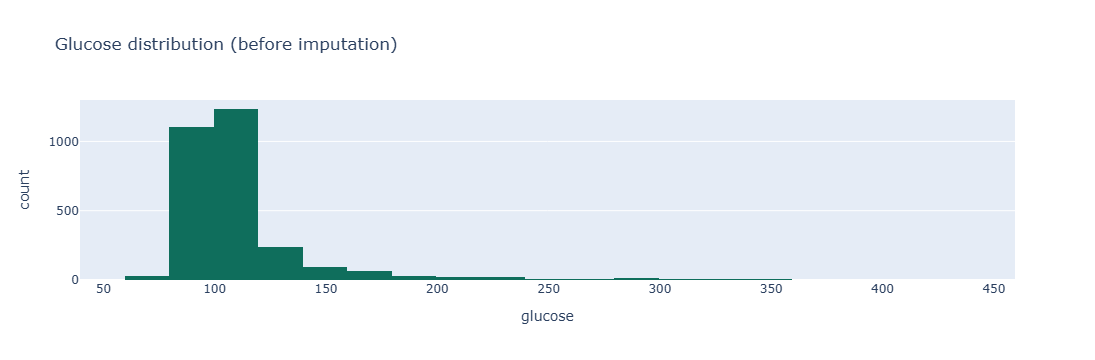

In [10]:
for col in ['glucose', 'bmi']:
    print(f'{col} skewness (before imputation): {eda[col].skew():.2f}')
px.histogram(eda, x='glucose', nbins=40, color_discrete_sequence=['#0f6e5c'],
             title='Glucose distribution (before imputation)').show()

**Interpretation.** Before imputation, glucose is highly right-skewed (**skew 4.01**) and BMI
only mildly so (**0.94**). The histogram shows glucose's long right tail. These baselines let us
judge whether imputation distorts the distribution.

### Imputing the missing values

We fill missing numeric values with the column median (robust to outliers and keeps
every row), as in the lecture.

**Caveat:** glucose is missing for ~69% of respondents (it is only measured on the
fasting subsample), so median-imputing it creates an artificial spike at the median -
visible below as the skewness *rising* after imputation. For glucose specifically,
analysing the fasting subsample is sounder than imputing; we impute here only to
demonstrate the technique.

In [11]:
num_cols = eda.select_dtypes('number').columns
eda_imp = eda.copy()
eda_imp[num_cols] = eda_imp[num_cols].fillna(eda_imp[num_cols].median())
print('Missing values after imputation:', int(eda_imp.isna().sum().sum()))

Missing values after imputation: 0


**Interpretation.** Median imputation removes all missing values (**0 remaining**). Median is
used rather than mean because it is robust to the right-tail outliers we just saw, so the fill
value is not dragged upward by extreme readings.

### Distributions after imputation

glucose skewness (after imputation): 7.59
bmi skewness (after imputation): 1.05


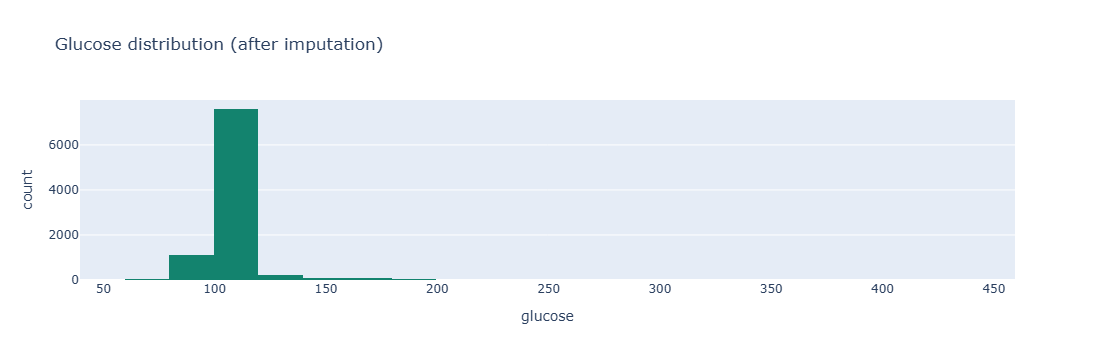

In [12]:
for col in ['glucose', 'bmi']:
    print(f'{col} skewness (after imputation): {eda_imp[col].skew():.2f}')
px.histogram(eda_imp, x='glucose', nbins=40, color_discrete_sequence=['#13836e'],
             title='Glucose distribution (after imputation)').show()

**Interpretation.** The cautionary result: glucose skew **rises from 4.01 to 7.59** after
imputation. Because glucose was 69% missing, filling those rows with one median value piled an
artificial spike at the centre, making the distribution *less* normal, not more. The lesson is
visible - median imputation is inappropriate for a column this sparse; analysing the fasting
subsample is sounder. BMI (6% missing) is barely affected (0.94 → 1.05), as imputation should
behave.

### Skewness recap

Skewness measures asymmetry: ~0 is symmetric, positive means a long right tail,
negative a long left tail.

In [13]:
eda_imp[num_cols].skew().sort_values().round(2).to_frame('skewness')

,skewness
height,-1.54
seqn,0.00
weight,0.13
age,0.28
bmi,1.05
diet_calories,1.91
diet_carbs,1.95
diet_fiber,1.99
diet_fat,2.02
diet_protein,2.06


**Interpretation.** Skewness across features: `height` is left-skewed (**-1.54**, children pull
the low end), the `diet_*` intake variables are strongly right-skewed (**~1.9–2.0**), and `age`/
`weight` are near-symmetric. Skewness flags which features might need a transformation before the
Phase-2 model.

### Confirming no missing values (missingno)

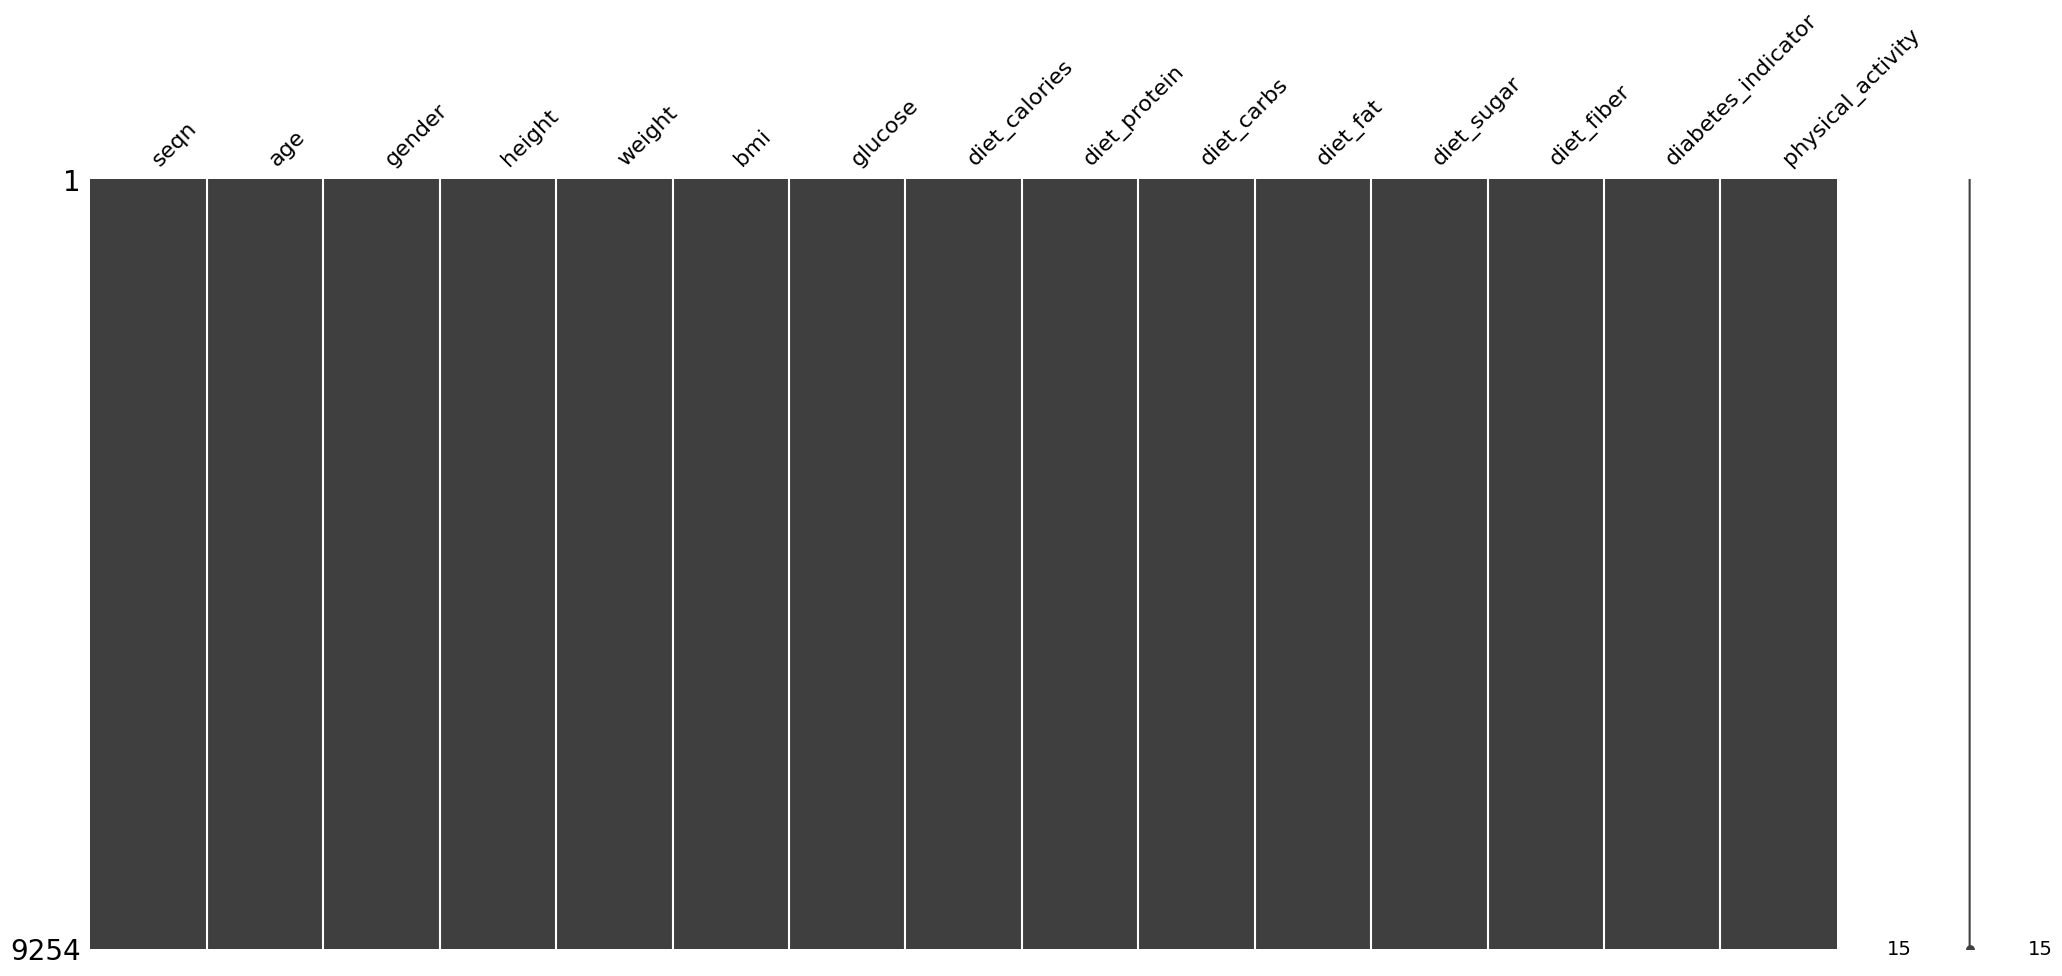

In [14]:
try:
    import missingno as msno
    import matplotlib.pyplot as plt
    msno.matrix(eda_imp)
    plt.show()
except Exception as exc:
    print('missingno not installed, showing a null map instead:', type(exc).__name__)
    px.imshow(eda_imp.isna().T, color_continuous_scale='Greys',
              title='Missing-value map (all False = no missing)').show()

**Interpretation.** The missingno matrix is a solid block with no white gaps - visual
confirmation that the imputed frame has **zero** missing values. The completeness check from the
notes, passed.

### Class balance

For the diabetes target we check how many respondents fall in each class - an
imbalanced target matters for the Phase 2 model.

      class  count
No diabetes   8000
   Diabetes    893


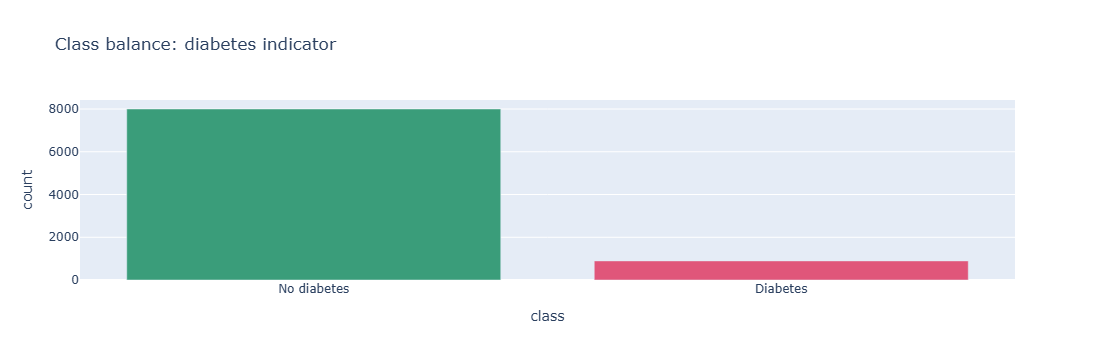

In [15]:
balance = (eda['diabetes_indicator'].map({0: 'No diabetes', 1: 'Diabetes'})
           .value_counts().reset_index())
balance.columns = ['class', 'count']
print(balance.to_string(index=False))
px.bar(balance, x='class', y='count', color='class', title='Class balance: diabetes indicator',
       color_discrete_sequence=['#3a9d7a', '#e0567a']).update_layout(showlegend=False).show()

**Interpretation.** The diabetes target is **imbalanced: 8,000 "No" vs 893 "Diabetes" (~10%
positive)**. This is the most consequential fact for Phase 2: a model that always predicts "No"
scores ~90% accuracy while being useless, so we will judge the Phase-2 model on precision, recall,
and ROC-AUC, and consider class-weighting or resampling.

### Scatter matrix

Pairwise relationships between the key numeric features, coloured by diabetes
status (Plotly's interactive equivalent of a scatter matrix).

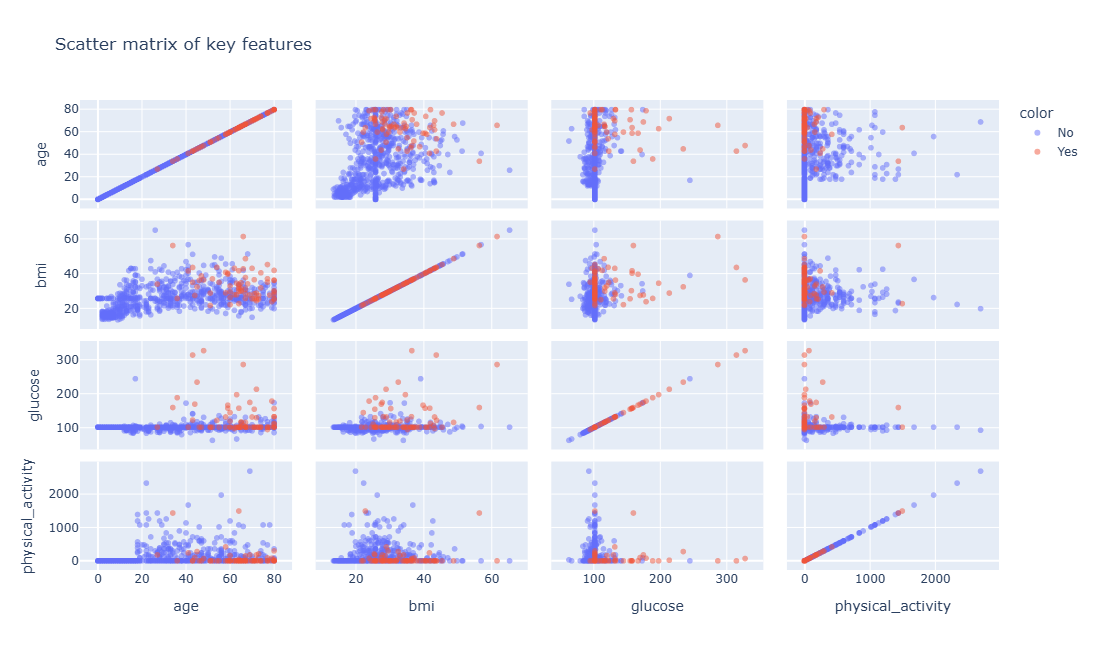

In [16]:
feats = ['age', 'bmi', 'glucose', 'physical_activity']
sample = eda_imp.dropna(subset=feats).sample(min(800, len(eda_imp)), random_state=42)
fig = px.scatter_matrix(sample, dimensions=feats,
                        color=sample['diabetes_indicator'].map({0: 'No', 1: 'Yes'}),
                        opacity=0.5, title='Scatter matrix of key features')
fig.update_layout(height=650)
fig.show()

**Interpretation.** The scatter matrix shows pairwise structure among age, BMI, glucose, and
activity. Diabetes cases concentrate toward higher glucose and BMI, but no single pair separates
the classes cleanly - which is exactly why a multivariate model (Phase 2) is needed rather than a
one-variable threshold.

### Pair plot coloured by Outcome (seaborn)

The seaborn pair plot from the lecture, on a sample for speed.

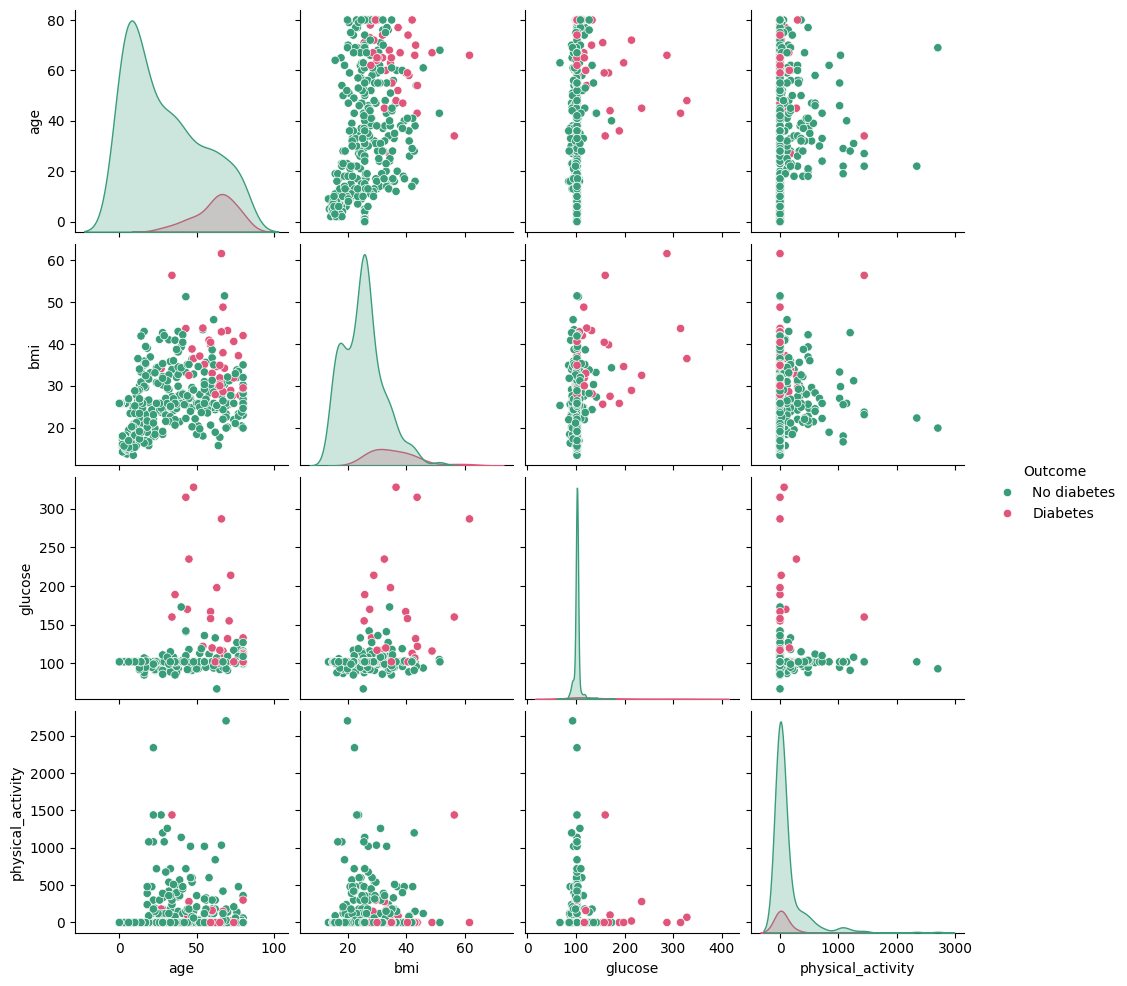

In [17]:
try:
    import seaborn as sns
    import matplotlib.pyplot as plt
    pp = eda_imp.dropna(subset=feats).copy()
    pp['Outcome'] = pp['diabetes_indicator'].map({0: 'No diabetes', 1: 'Diabetes'})
    sns.pairplot(pp.sample(min(400, len(pp)), random_state=42), vars=feats, hue='Outcome',
                 palette={'No diabetes': '#3a9d7a', 'Diabetes': '#e0567a'})
    plt.show()
except Exception as exc:
    print('seaborn not installed; the Plotly scatter matrix above is the equivalent view.', type(exc).__name__)

**Interpretation.** The seaborn pair plot tells the same story with density curves on the
diagonal: the Diabetes group's glucose and BMI distributions sit visibly to the right of the
No-diabetes group, while `age` overlaps more. Glucose is the most separating single feature.

### Z-score and the empirical rule (68-95-99.7)

Standardising glucose to z-scores lets us check the empirical rule: for a roughly
normal distribution about 68% / 95% / 99.7% of values fall within 1 / 2 / 3
standard deviations of the mean.

In [18]:
# Use the OBSERVED (non-imputed) glucose so the rule reflects the real distribution.
g = eda['glucose'].dropna()
z = (g - g.mean()) / g.std()
for k, expected in zip((1, 2, 3), (68, 95, 99.7)):
    pct = (z.abs() <= k).mean() * 100
    print(f'Within {k} std: {pct:5.1f}%   (empirical rule expects ~{expected}%)')
print('\nThe percentages depart from 68-95-99.7 because glucose is right-skewed,')
print('not normal -- a meaningful finding, not a clean textbook match.')

Within 1 std:  90.8%   (empirical rule expects ~68%)
Within 2 std:  95.8%   (empirical rule expects ~95%)
Within 3 std:  97.5%   (empirical rule expects ~99.7%)

The percentages depart from 68-95-99.7 because glucose is right-skewed,
not normal -- a meaningful finding, not a clean textbook match.


**Interpretation.** On the real (non-imputed) glucose, **90.8%** of values fall within 1 SD
versus the ~68% a normal distribution predicts, and the 2-/3-SD bands are also tighter than
expected. This quantifies the right-skew - the distribution is sharply peaked with a long thin
tail, so it is not normal. A model using glucose may benefit from a log transform.

### EDA recap

We confirmed structure and summary statistics, diagnosed missing values (notably
glucose, missing for ~69% because it is only measured on the fasting subsample),
demonstrated median imputation while noting its limitation for heavily-missing
columns, examined skewness before and after, verified completeness with missingno,
checked class balance, and explored relationships with a scatter matrix and pair plot.

Two findings shape Phase 2: the diabetes target is **imbalanced (~10% positive)**, and
glucose is **strongly right-skewed** (its empirical-rule percentages depart from
68-95-99.7). Both will influence model choice and evaluation.

## Section 5 - Descriptive Statistics

In [19]:
food_stats = foods[['calories','protein','carbs','fat','sugar']].agg(['mean','median','std']).T
health_stats = nhanes[['bmi','glucose']].agg(['mean','median','std']).T
display(pd.concat([food_stats, health_stats]).round(2))

C:\Users\Abhijith Nallana\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,mean,median,std
calories,187.75,115.55,176.03
protein,10.02,7.33,10.16
carbs,18.80,7.50,25.20
fat,8.63,1.48,15.49
sugar,NaN,NaN,NaN
bmi,26.58,25.80,8.26
glucose,111.80,102.00,35.53


**Interpretation.** The combined summary contrasts both domains on one screen: USDA foods span a
wide calorie range (energy-dense nuts/oils vs low-calorie produce), while the NHANES markers
(mean BMI ~26, right-skewed glucose) describe the survey population. This bridges the food
reference and the health survey before the focused analyses.

## Section 6 - Nutrition Analysis

,food_name,calories
48,"Oil, coconut",833.000000
172,"Nuts, pecans, halves, raw",699.596440
171,"Nuts, walnuts, English, halves, raw",678.664340
207,"Nuts, macadamia nuts, raw",668.544280
44,"Egg, yolk, dried",654.000000
153,"Sesame butter, creamy",648.374268
169,"Nuts, pine nuts, raw",642.992280
9,"Nuts, almonds, dry roasted, with salt added",621.000000
202,"Nuts, brazilnuts, raw",620.950526
24,"Seeds, sunflower seed kernels, dry roasted, wi...",612.000000


,food_name,protein
14,"Egg, white, dried",79.90000
96,"Flour, soy, defatted",51.10000
42,"Egg, whole, dried",48.10000
83,"Pork, cured, bacon, cooked, restaurant",40.90000
97,"Flour, soy, full-fat",38.60000
44,"Egg, yolk, dried",34.20000
51,"Chicken, broiler or fryers, breast, skinless, ...",32.10000
147,"Cheese, parmesan, grated, refrigerated",30.13912
209,"Seeds, pumpkin seeds (pepitas), raw",29.90790
20,"Cheese, parmesan, grated",29.60000


,food_name,sugar
0,"Hummus, commercial",NaN
1,"Milk, reduced fat, fluid, 2% milkfat, with add...",NaN
2,"Tomatoes, grape, raw",NaN
3,"Beans, snap, green, canned, regular pack, drai...",NaN
4,"Broccoli, raw",NaN
5,"Milk, lowfat, fluid, 1% milkfat, with added vi...",NaN
6,"Milk, nonfat, fluid, with added vitamin A and ...",NaN
7,"Milk, whole, 3.25% milkfat, with added vitamin D",NaN
8,"Frankfurter, beef, unheated",NaN
9,"Nuts, almonds, dry roasted, with salt added",NaN


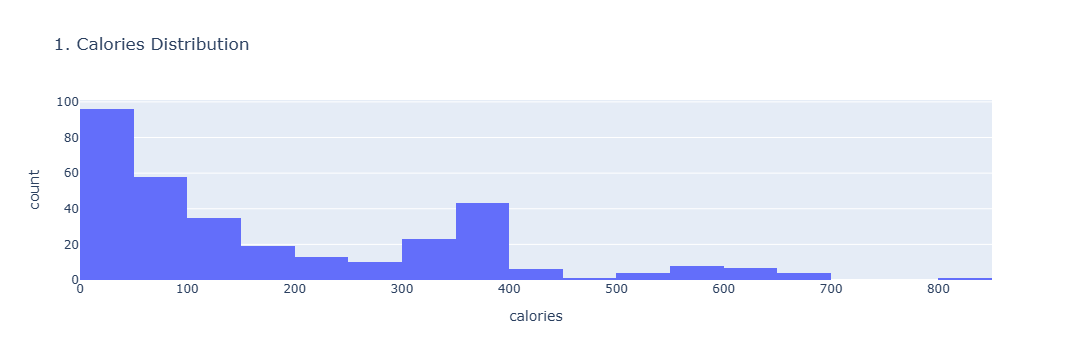

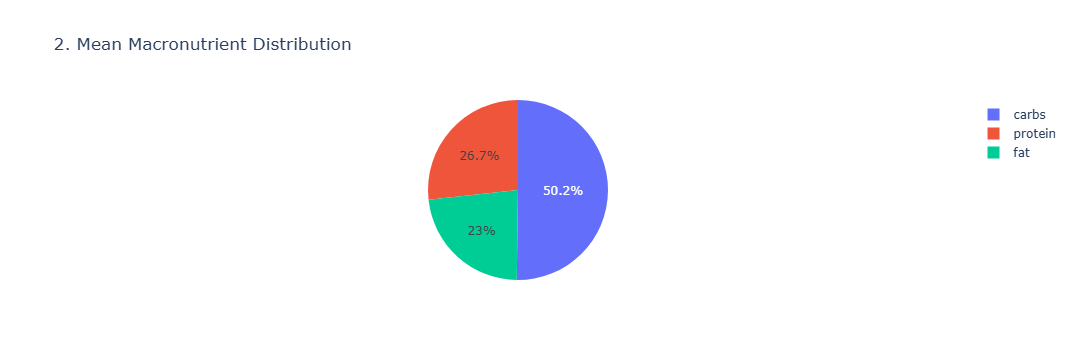

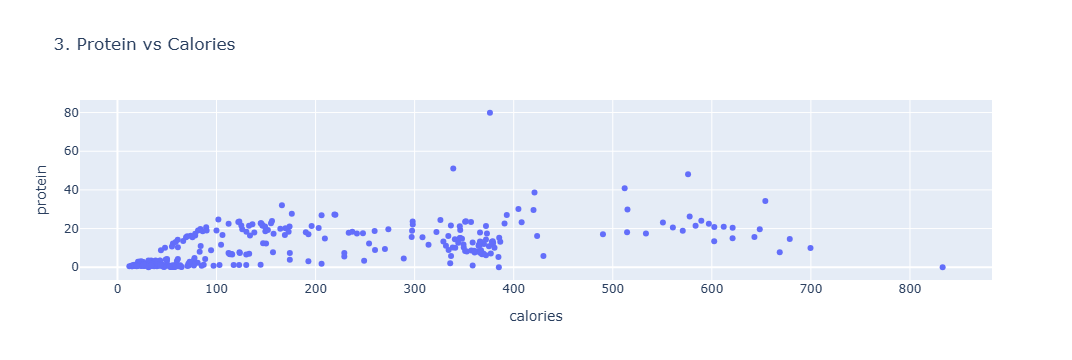

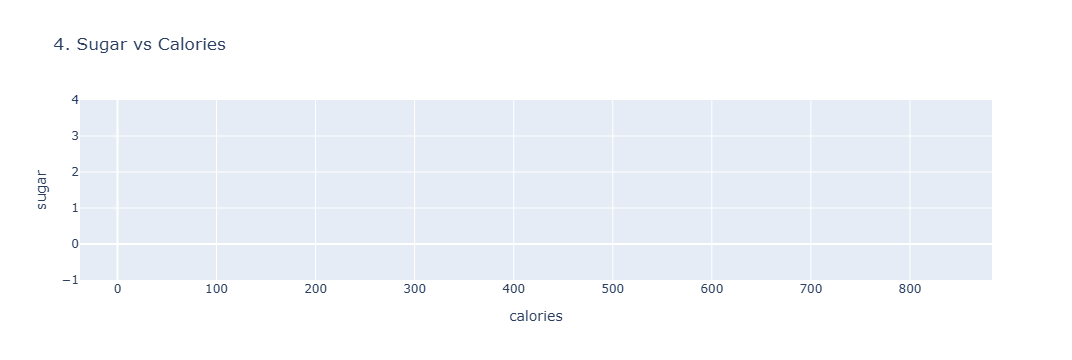

In [20]:
display(foods.nlargest(10, 'calories')[['food_name','calories']])
display(foods.nlargest(10, 'protein')[['food_name','protein']])
display(foods.nlargest(10, 'sugar')[['food_name','sugar']])
px.histogram(foods, x='calories', nbins=40, title='1. Calories Distribution').show()
macro_means = foods[['protein','carbs','fat']].mean().reset_index(); macro_means.columns=['macronutrient','mean_grams']
px.pie(macro_means, names='macronutrient', values='mean_grams', title='2. Mean Macronutrient Distribution').show()
px.scatter(foods, x='calories', y='protein', hover_name='food_name', title='3. Protein vs Calories').show()
px.scatter(foods, x='calories', y='sugar', hover_name='food_name', title='4. Sugar vs Calories').show()

**Interpretation (charts 1–4 + top-10 tables).** Calories are right-skewed across the catalog -
most foods low-to-moderate, a small high-energy tail. The macronutrient pie shows carbohydrate as
the largest component by mass on average. Protein-vs-Calories and Sugar-vs-Calories show calories
rising with protein but driven harder by fat (high-fat foods sit above the trend), while sugar
relates only weakly to calories. The top-10 tables are led by nuts/oils (calories) and
meats/legumes (protein).

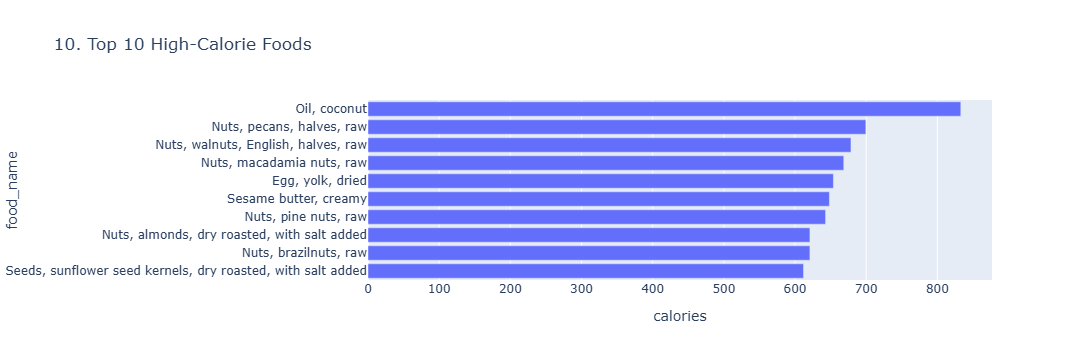

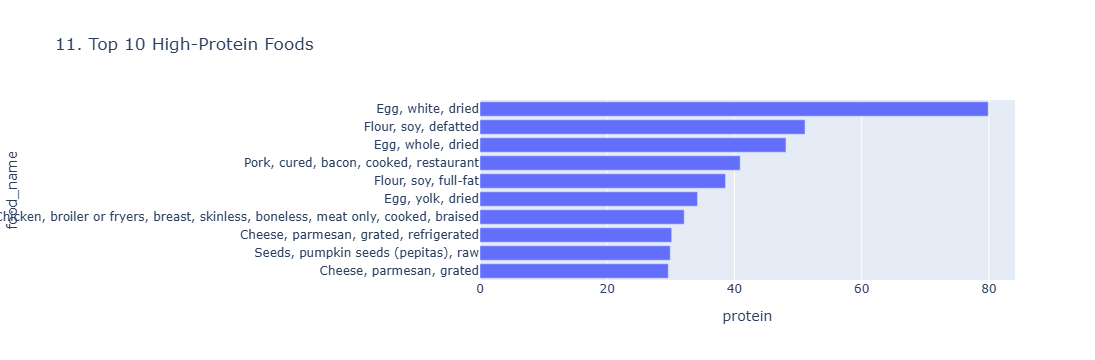

In [21]:
px.bar(foods.nlargest(10,'calories').sort_values('calories'), x='calories', y='food_name', orientation='h', title='10. Top 10 High-Calorie Foods').show()
px.bar(foods.nlargest(10,'protein').sort_values('protein'), x='protein', y='food_name', orientation='h', title='11. Top 10 High-Protein Foods').show()

**Interpretation (charts 10–11).** The horizontal bars rank the most energy-dense and
protein-dense foods. Nuts, seeds, and oils top the calorie list; meats, fish, and legumes top the
protein list - directly useful for the app's food recommendations.

## Section 7 - Diabetes Insights Analysis
These are unadjusted descriptive associations and do not establish causation. NHANES has a complex survey design; a publication-quality analysis should apply survey weights, strata, and PSU variables.

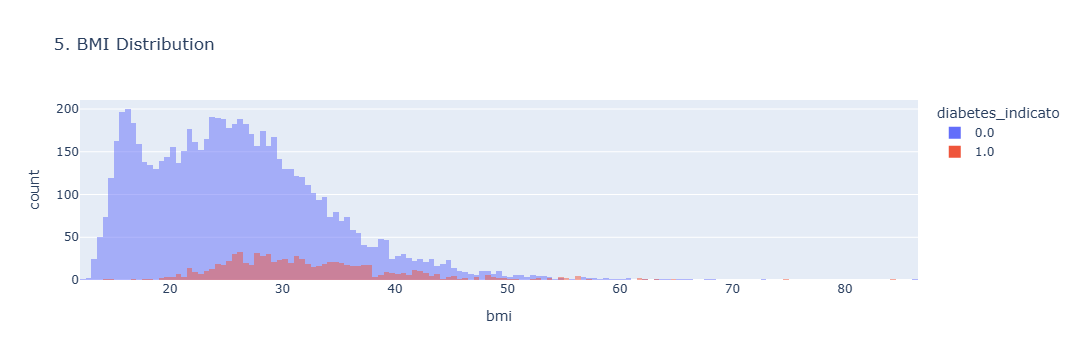

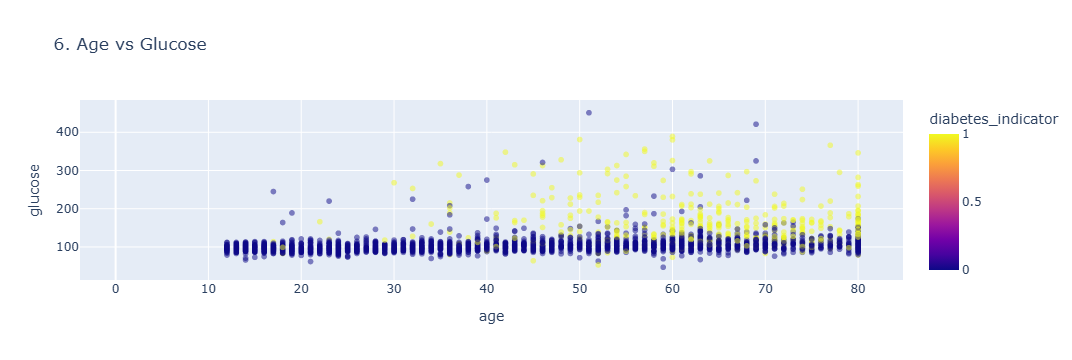

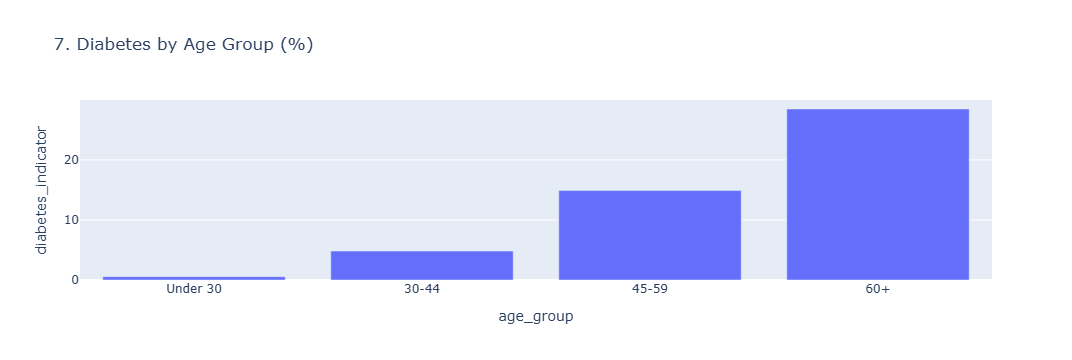

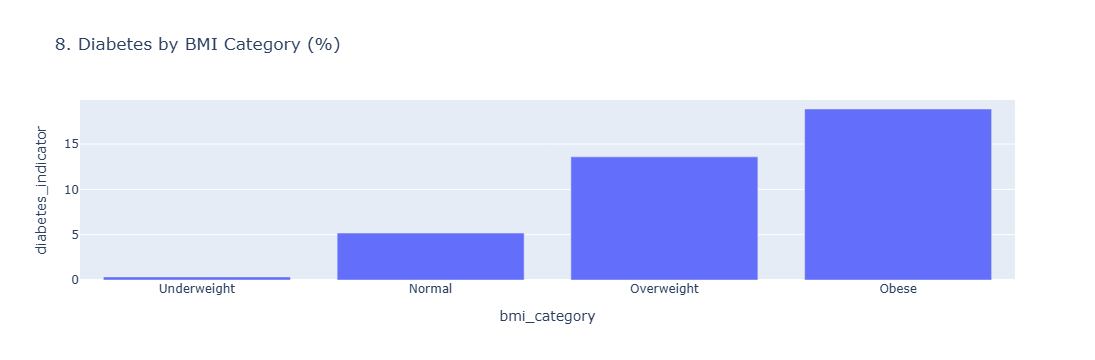

In [22]:
analysis = nhanes.dropna(subset=['diabetes_indicator']).copy()
analysis['age_group'] = pd.cut(analysis['age'], [0,29,44,59,120], labels=['Under 30','30-44','45-59','60+'])
analysis['bmi_category'] = pd.cut(analysis['bmi'], [0,18.5,25,30,np.inf], labels=['Underweight','Normal','Overweight','Obese'])
px.histogram(analysis, x='bmi', color='diabetes_indicator', barmode='overlay', title='5. BMI Distribution').show()
px.scatter(analysis, x='age', y='glucose', color='diabetes_indicator', opacity=.5, title='6. Age vs Glucose').show()
px.bar(analysis.groupby('age_group', observed=True)['diabetes_indicator'].mean().mul(100).reset_index(), x='age_group', y='diabetes_indicator', title='7. Diabetes by Age Group (%)').show()
px.bar(analysis.groupby('bmi_category', observed=True)['diabetes_indicator'].mean().mul(100).reset_index(), x='bmi_category', y='diabetes_indicator', title='8. Diabetes by BMI Category (%)').show()

**Interpretation (charts 5–8).** Every risk factor moves as expected. The diabetes group's BMI is
shifted right (chart 5) and glucose clearly elevated across ages (chart 6). Diabetes prevalence
climbs steeply with **age** - 0.6% under 30 to **28.5%** at 60+ (chart 7) - and with **BMI** - 0.3%
underweight to **18.9%** obese (chart 8). These monotonic gradients are textbook type-2 risk
patterns, reproduced in real NHANES data.

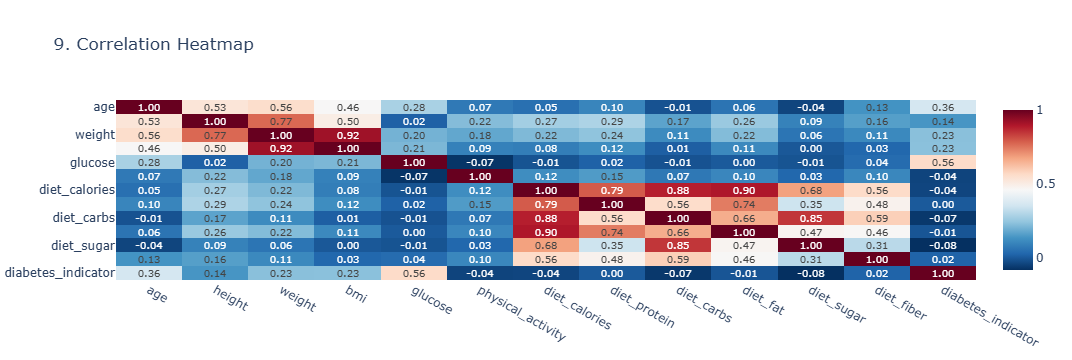

,No diabetes,Diabetes
age,32.68,62.79
bmi,25.92,32.22
glucose,103.60,160.65
physical_activity,146.27,94.72
diet_calories,2030.52,1904.45
diet_protein,74.13,74.34
diet_carbs,246.69,220.11
diet_fat,81.05,79.84
diet_sugar,108.62,89.00
diet_fiber,15.60,16.30


In [23]:
corr_cols = ['age','height','weight','bmi','glucose','physical_activity','diet_calories','diet_protein','diet_carbs','diet_fat','diet_sugar','diet_fiber','diabetes_indicator']
px.imshow(analysis[corr_cols].corr(), text_auto='.2f', aspect='auto', color_continuous_scale='RdBu_r', title='9. Correlation Heatmap').show()
comparison = analysis.groupby('diabetes_indicator')[['age','bmi','glucose','physical_activity','diet_calories','diet_protein','diet_carbs','diet_fat','diet_sugar','diet_fiber']].mean().T
comparison.columns = ['No diabetes','Diabetes']
display(comparison.round(2))

### Interpretation of the correlation heatmap and group comparison

The heatmap and group means quantify what the charts suggested. Correlation with the diabetes
indicator is led by **glucose (0.56)**, then **age (0.36)** and **BMI (0.23)**; dietary variables
are near zero. The group means make it concrete (*No diabetes → Diabetes*):

- **Glucose:** 103.6 → **160.6** mg/dL (largest separation)
- **Age:** 32.7 → **62.8** years
- **BMI:** 25.9 → **32.2**
- **Physical activity:** 146.3 → **94.7** weekly minutes (lower in the diabetes group)
- **Sugar intake:** 108.6 → **89.0** g/day (slightly *lower* in the diabetes group)

The lower sugar/calorie intake among diagnosed diabetics is a strong viva point: it most likely
reflects **reverse behaviour** - people who know they have diabetes modify their diet - rather than
sugar protecting against diabetes. A clean example of why these are **associations, not causation**,
especially given NHANES is self-reported with a complex survey design (weights/strata not applied).

## Save cleaned real-data tables and create SQLite database

In [24]:
foods.to_csv(PROCESSED_DIR / 'foods.csv', index=False)
nhanes.to_csv(PROCESSED_DIR / 'nhanes.csv', index=False)
with sqlite3.connect(DB_PATH) as connection:
    foods.to_sql('foods', connection, if_exists='replace', index=False)
    nhanes.to_sql('nhanes', connection, if_exists='replace', index=False)
    connection.execute('CREATE INDEX IF NOT EXISTS idx_foods_name ON foods(food_name)')
print(f'Database created: {DB_PATH}')
print('foods:', len(foods), '| nhanes:', len(nhanes))

Database created: C:\Users\Abhijith Nallana\Desktop\data-science-roadmap\Project\database\nutritrack.db
foods: 328 | nhanes: 9254


In [25]:
# Cross-check: confirm the tables were actually written, with the expected row counts.
with sqlite3.connect(DB_PATH) as connection:
    tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", connection)
    print('Tables in database:', tables['name'].tolist())
    for table in ['foods', 'nhanes']:
        count = pd.read_sql(f'SELECT COUNT(*) AS n FROM {table}', connection)['n'][0]
        print(f'  {table:8} -> {count:,} rows')
    print('\nSample of stored foods:')
    display(pd.read_sql('SELECT food_name, calories, protein FROM foods LIMIT 5', connection))

Tables in database: ['foods', 'meal_log', 'nhanes', 'profiles', 'sqlite_sequence']
  foods    -> 328 rows
  nhanes   -> 9,254 rows

Sample of stored foods:


,food_name,calories,protein
0,"Hummus, commercial",229.0,7.35
1,"Milk, reduced fat, fluid, 2% milkfat, with add...",50.0,3.35
2,"Tomatoes, grape, raw",27.0,0.83
3,"Beans, snap, green, canned, regular pack, drai...",20.0,1.04
4,"Broccoli, raw",32.0,2.57


**Interpretation.** This confirms the write succeeded: the database now contains the
`foods` and `nhanes` tables with **328** and **9,254** rows - matching the counts printed
when we saved. The sample rows show real USDA food names and values, verifying that genuine
data (not placeholders) was stored. The `profiles` and `meal_log` tables, if present, are
created by the Streamlit app and start empty, which is expected.

## Conclusion

**What Phase 1 delivered.** We loaded the official USDA Foundation Foods and NHANES 2017–2018 files,
cleaned them honestly (no invented values), ran a complete EDA mirroring the course syllabus, and
produced descriptive diabetes-risk insights - then persisted the cleaned `foods` (328) and `nhanes`
(9,254) tables to SQLite for the Streamlit app.

**Key findings.**
1. Glucose, age, and BMI are the markers most associated with diabetes; diet variables are weakly
   (even negatively) associated, likely from post-diagnosis behaviour change.
2. Diabetes prevalence rises monotonically with age (0.6% → 28.5%) and BMI (0.3% → 18.9%).
3. Glucose is strongly right-skewed and ~69% missing by survey design, so it must be handled
   carefully - not naively imputed.
4. The target is imbalanced (~10% positive), which dictates the Phase-2 evaluation strategy.

**Limitations.** Associations are unadjusted and not causal; the sample includes all ages (children
inflate the "No diabetes" group); diet and diagnosis are self-reported; NHANES survey weights/strata
were not applied.

**Next (Phase 2).** Build a diabetes-prediction model on the cleaned `nhanes` table - leading with
glucose, age, and BMI - using a train/test split, cross-validation, and imbalance-aware metrics
(precision, recall, ROC-AUC), as the back half of the course notes describe.